<a href="https://colab.research.google.com/github/dishneetgill/cap-comp215/blob/2026.01/copy_of_project301.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Biometric Identification System Simulation
This model takes a fingerprint as input and processes it using the algorithm SIFT. It then compares the fingerprint to a number of fingerprints in a database and finds the best match. A person can then be identified and some of their personal data can be retrieved. In other words, this model simulates the process of how biometric systems in the real world use fingerprint data in order to identify individuals.

In [ ]:
import zipfile
import os
import shutil
import cv2
import numpy as np
import matplotlib.pyplot as plt
import gdown

To begin implementating this model, we first need soome fingerprint data (i.e. images) that we can use to compare against a dataset of biometric identities. We used a publicly available dataset repository to download some images as a zip file-https://github.com/fdhhhdjd/AI-Fingerprint-Datasets.

In [ ]:
#Download zip file from Google Drive
file_id = '15-4urolciLZJf4SdypWyigl8jLOGtSNS'
output = 'fingerprints.zip'

gdown.download(f"https://drive.google.com/uc?id={file_id}", output, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=15-4urolciLZJf4SdypWyigl8jLOGtSNS
From (redirected): https://drive.google.com/uc?id=15-4urolciLZJf4SdypWyigl8jLOGtSNS&confirm=t&uuid=29746346-2996-4e85-affb-0842e316e117
To: /content/fingerprints.zip
100%|██████████| 870M/870M [00:10<00:00, 79.2MB/s]


'fingerprints.zip'

We then need to extract the zip file so that the .tif image files become accessible and the image file paths can be processed. Since there are many different folders in this archive, we focus on images from one folder 'Db1_a', which contains a subset of images for the year 2000.

get_finger_print(zip_file, target_folder='Db1_a') – This function goes digging through that massive zip file like a detective
searching for evidence. It extracts everything, then carefully filters through folder after folder until it finds exactly the
'Db1_a' directory, grabbing every single .tif fingerprint image it can find and returning a complete list of their file paths.

In [ ]:
#Written with assistance from ChatGPT
def get_finger_print(zip_file, target_folder='Db1_a'):
    """
    Extracts the zip file and returns the path of the fingerprint images.
    """
    extract_dir = 'fingerprint_data'

    if os.path.exists(extract_dir):
        shutil.rmtree(extract_dir)

    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)

    finger_prints = []
    for root, _, files in os.walk(extract_dir):
        if target_folder in root:
            for file in files:
                if file.lower().endswith('.tif'):
                    finger_prints.append(os.path.join(root, file))

    return finger_prints

We then need a biometric identity dataset in order to link fingerprint data to identities so that individuals can be identified through the system. For the sake of this project we just prompted ChatGPT to create a fake dataset for ten people. The biometric identities are created by linking each user's record in the dataset to a fingerprint file path created in the previous step.

In [ ]:
#Asked ChatGPT to create personal records for ten made up people
dataset = [
    {
        "user_id": "U001",
        "full_name": "Liam Chen",
        "age": 28,
        "email": "liam.chen@example.com",
        "phone": "+1-604-555-1023",
        "address": "123 Main St, Vancouver, BC",
        "occupation": "Software Developer",
    },
    {
        "user_id": "U002",
        "full_name": "Sofia Martinez",
        "age": 34,
        "email": "sofia.martinez@example.com",
        "phone": "+1-778-555-3345",
        "address": "456 Oak Ave, Burnaby, BC",
        "occupation": "Nurse",
    },
    {
        "user_id": "U003",
        "full_name": "Ethan Patel",
        "age": 41,
        "email": "ethan.patel@example.com",
        "phone": "+1-604-555-8890",
        "address": "789 Pine Rd, Surrey, BC",
        "occupation": "Business Owner",
    },
    {
        "user_id": "U004",
        "full_name": "Olivia Thompson",
        "age": 25,
        "email": "olivia.thompson@example.com",
        "phone": "+1-236-555-7781",
        "address": "321 Maple Dr, Richmond, BC",
        "occupation": "Student",
    },
    {
        "user_id": "U005",
        "full_name": "Noah Dubois",
        "age": 37,
        "email": "noah.dubois@example.com",
        "phone": "+1-604-555-6612",
        "address": "654 Cedar St, North Vancouver, BC",
        "occupation": "Architect",
    },
    {
        "user_id": "U006",
        "full_name": "Ava Singh",
        "age": 30,
        "email": "ava.singh@example.com",
        "phone": "+1-778-555-4499",
        "address": "987 Birch Ln, Coquitlam, BC",
        "occupation": "Data Analyst",
    },
    {
        "user_id": "U007",
        "full_name": "Lucas Brown",
        "age": 45,
        "email": "lucas.brown@example.com",
        "phone": "+1-604-555-2201",
        "address": "159 Spruce St, Delta, BC",
        "occupation": "Police Officer",
    },
    {
        "user_id": "U008",
        "full_name": "Mia Nguyen",
        "age": 22,
        "email": "mia.nguyen@example.com",
        "phone": "+1-236-555-6677",
        "address": "753 Willow Ave, Langley, BC",
        "occupation": "Retail Worker",
    },
    {
        "user_id": "U009",
        "full_name": "Daniel Kim",
        "age": 39,
        "email": "daniel.kim@example.com",
        "phone": "+1-778-555-8844",
        "address": "852 Elm St, Vancouver, BC",
        "occupation": "Cybersecurity Specialist",
    },
    {
        "user_id": "U010",
        "full_name": "Emily Johnson",
        "age": 31,
        "email": "emily.johnson@example.com",
        "phone": "+1-604-555-9933",
        "address": "246 Aspen Rd, West Vancouver, BC",
        "occupation": "Marketing Manager",
    }
]

#Give each user in the dataset a biometric identity by linking each of them to a unique fingerprint path
zip_file = 'fingerprints.zip'
finger_prints = get_finger_print(zip_file, 'Db1_a')

for index, record in enumerate(dataset):
    if index < len(finger_prints):
        record["fingerprint_path"] = finger_prints[index]

print(dataset)

[{'user_id': 'U001', 'full_name': 'Liam Chen', 'age': 28, 'email': 'liam.chen@example.com', 'phone': '+1-604-555-1023', 'address': '123 Main St, Vancouver, BC', 'occupation': 'Software Developer', 'fingerprint_path': 'fingerprint_data/74034_3_En_4_MOESM1_ESM/FVC2002/Dbs/Db1_a/52_8.tif'}, {'user_id': 'U002', 'full_name': 'Sofia Martinez', 'age': 34, 'email': 'sofia.martinez@example.com', 'phone': '+1-778-555-3345', 'address': '456 Oak Ave, Burnaby, BC', 'occupation': 'Nurse', 'fingerprint_path': 'fingerprint_data/74034_3_En_4_MOESM1_ESM/FVC2002/Dbs/Db1_a/74_6.tif'}, {'user_id': 'U003', 'full_name': 'Ethan Patel', 'age': 41, 'email': 'ethan.patel@example.com', 'phone': '+1-604-555-8890', 'address': '789 Pine Rd, Surrey, BC', 'occupation': 'Business Owner', 'fingerprint_path': 'fingerprint_data/74034_3_En_4_MOESM1_ESM/FVC2002/Dbs/Db1_a/42_4.tif'}, {'user_id': 'U004', 'full_name': 'Olivia Thompson', 'age': 25, 'email': 'olivia.thompson@example.com', 'phone': '+1-236-555-7781', 'address': '

Now that we have the fingerprint images we want to use, they must be processed to ensure that they are in a format suitable for comparison in later steps, and to ensure reliable results.

load_fingerprint(path) – This function takes a raw fingerprint image and puts it through a rigorous makeover. First, it opens the
file and checks if it even exists. Then, if the image is in color, it strips all that unnecessary information away and converts it
to clean grayscale. Finally, it forces every pixel value into a perfect 0-to-255 range, leaving behind a beautifully standardized
fingerprint ready for serious analysis.


In [ ]:
#Written with assistance from ChatGPT
def load_fingerprint(path):
    """
    Loads and reads a fingerprint image from inputed path and verifies it is in a suitable format by
    converting it to greyscale and normalizing the pixel values (8-bit). The processed image is then
    returned.
    """
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)

    if img is None:
        raise ValueError(f"Could not read image: {path}")

    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    if img.dtype != np.uint8:
        img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)
        img = img.astype(np.uint8)

    return img

compare_fingerprints(path1, path2) – This is where the real action happens. The function loads both fingerprints, then unleashes the
 SIFT algorithm to hunt down hundreds of unique little landmarks in each image. After that, it brings in a brute-force matcher that
 pits every feature from the first print against every feature from the second, keeping only the matches that pass an aggressive
 quality filter. The final number it returns tells you exactly how many genuine connections were found between the two fingerprints.

In [ ]:
#Written with assistance from ChatGPT
def compare_fingerprints(path1, path2):
    """
    Takes in two fingerprint images and ensures they are in the correct format. Then uses SIFT to find
    unique points in the fingerprints and uses a brute force matcher to compare them. Good matches are
    filtered using Lowe's ratio test and the number of good matches is returned.
    """
    image1 = load_fingerprint(path1)
    image2 = load_fingerprint(path2)

    sift = cv2.SIFT_create()

    kp1, des1 = sift.detectAndCompute(image1, None)
    kp2, des2 = sift.detectAndCompute(image2, None)

    if des1 is None or des2 is None:
        return 0

    bf = cv2.BFMatcher()

    matches = bf.knnMatch(des1, des2, k=2)

    good_matches = []
    for m, n in matches:
        if m.distance < 0.75 * n.distance:
            good_matches.append(m)

    return len(good_matches)

We can now use the function created above to compare inputed fingerprints with the fingerprints in the biometric dataset from earlier.

find_matching_user(input_fingerprint_path, database, threshold=70) – This function works like a security guard checking an ID at a
VIP club. It takes your input fingerprint and compares it against every single person in the database, one by one, keeping a running
tally of who scores highest. Only when the best score clears the threshold bar does it hand over that person's full record. If nobody
 meets the standard, it admits defeat and tells you no match was found.

In [ ]:
def find_matching_user(input_fingerprint_path, database, threshold=70):
    """
    Takes a fingerprint as input and compares it to all fingerprints in the database,then finds and returns the best match based on a threshold
    value.
    """
    user_found = None
    highest_score = -1

    for user in database:
        stored_path = user.get("fingerprint_path")

        score = compare_fingerprints(input_fingerprint_path, stored_path)

        if score > highest_score:
            highest_score = score
            user_found = user

    if highest_score >= threshold:
        return user_found, highest_score

    return None, highest_score

We want to have a visual representation of the results so that we can confirm the correctness of the fingerprint match with our own eyes. This is done by displaying the inputed fingerprint image beside the matched fingerprint image

show_match(input_path, matched_path) – This function is all about visual proof. It grabs both fingerprints and places them side by
 side like a police lineup. The input fingerprint goes on the left, the matched fingerprint on the right, giving you the satisfying
 experience of seeing with your own eyes whether the system made a smart decision or a terrible mistake.

In [ ]:
def show_match(input_path, matched_path):
    """
    Asked ChatGPT to write a visual demo function that displays the input fingerprint and the matched fingerprint side by side.
    """
    img1 = cv2.imread(input_path, cv2.IMREAD_GRAYSCALE)
    img2 = cv2.imread(matched_path, cv2.IMREAD_GRAYSCALE)

    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(img1, cmap='gray')
    plt.title("Input Fingerprint")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(img2, cmap='gray')
    plt.title("Matched Fingerprint")
    plt.axis('off')

    plt.show()

find_match(path, dataset) – This is the friendly assistant that does everything for you. You just hand it a fingerprint path, and it
quietly calls all the heavy-lifting functions behind the scenes. If it finds a match, it proudly displays the side-by-side images,
announces the person's full name like a game show host, and shares their email. If not, it simply shrugs and says "No match found."

In [ ]:
def find_match(path, dataset):
  """
  Takes a fingerprint as input and compares it to all fingerprints in the database,then determines whether there is a valid match. If valid match
  is found, then an image is displayed showing the input fingerprint and the matched fingerprint, and the matched user's full name and email
  is printed.
  """
  match, score = find_matching_user(path, dataset)

  if match:
      show_match(path, match["fingerprint_path"])
      print(f"Match found with user: {match['full_name']}")
      print(f"Email: {match['email']}")
  else:
      print("No match found")

test_threshold_performance(dataset, test_user_index=3, wrong_user_index=5) – This function acts like a stress test for the entire system.
 It takes one person's fingerprint and compares it against both their own print and someone else's, running these tests repeatedly
 with different threshold values. The results reveal exactly when the system becomes too paranoid (rejecting the real owner), too
 careless (letting imposters in), or perfectly balanced.

In [ ]:
# THRESHOLD ANALYSIS FUNCTION (DISHNEET) Finding the best match sensitivity
# I have tried to make a function that tests different threshold values to see which ones correctly accept a person's own-
# -fingerprint and reject someone else's fingerprint.
def test_threshold_performance(dataset, test_user_index=3, wrong_user_index=5):
    """
    Tests different threshold values to show why threshold selection matters.
    Shows both correct matches and false matches.
    """

    # Get test fingerprints
    correct_fp = dataset[test_user_index]["fingerprint_path"]
    wrong_fp = dataset[wrong_user_index]["fingerprint_path"]

    thresholds = [30, 50, 70, 90, 110, 130]

    print("THRESHOLD PERFORMANCE TEST")
    print(f"Testing with: {dataset[test_user_index]['full_name']}'s fingerprint")
    print(f"Comparing against correct match vs wrong person ({dataset[wrong_user_index]['full_name']})\n")

    print(f"{'Threshold':<12} {'Correct Match Score':<20} {'Wrong Match Score':<20} {'Result'}")

    for t in thresholds:
        # Compare correct match
        correct_score = compare_fingerprints(correct_fp, correct_fp)

        # Compare wrong match
        wrong_score = compare_fingerprints(correct_fp, wrong_fp)

        # Determine outcomes
        correct_accept = correct_score >= t
        wrong_accept = wrong_score >= t

        if correct_accept and not wrong_accept:
            result = "IDEAL"
        elif correct_accept and wrong_accept:
            result = "UNSAFE (False Accept)"
        elif not correct_accept and not wrong_accept:
            result = "TOO STRICT (False Reject)"
        else:
            result = "FAIL"

        print(f"{t:<12} {correct_score:<20} {wrong_score:<20} {result}")

    print("\n  Lower thresholds = easier access but less secure")
    print("   Higher thresholds = more secure but may reject valid users")
    print(f"   Current threshold (70) balances both for this test\n")


def find_match_with_custom_threshold(path, dataset, custom_threshold):
    """
    Same as find_match but with adjustable threshold.
    Shows how changing threshold affects results.
    """
    match, score = find_matching_user(path, dataset, threshold=custom_threshold)

    if match:
        print(f"\n ACCESS GRANTED (Threshold: {custom_threshold})")
        print(f"   Match confidence: {score} points")
        print(f"   User: {match['full_name']}")
        print(f"   ID: {match['user_id']}")
        return True
    else:
        print(f"\n ACCESS DENIED (Threshold: {custom_threshold})")
        print(f"   Best match score: {score} points (below {custom_threshold})")
        return False
# Run the analysis
test_threshold_performance(dataset, test_user_index=3, wrong_user_index=5)

# Demonstrate the trade-off
print("DEMO for SAME FINGERPRINT, DIFFERENT THRESHOLDS")

test_fp = dataset[3]["fingerprint_path"]

print("\n LOW THRESHOLD (50) - Easy access but risky")
find_match_with_custom_threshold(test_fp, dataset, 50)

print("\n MEDIUM THRESHOLD (70) - Current setting")
find_match_with_custom_threshold(test_fp, dataset, 70)

print("\n HIGH THRESHOLD (120) - Very strict")
find_match_with_custom_threshold(test_fp, dataset, 120)

THRESHOLD PERFORMANCE TEST
Testing with: Olivia Thompson's fingerprint
Comparing against correct match vs wrong person (Ava Singh)

Threshold    Correct Match Score  Wrong Match Score    Result
30           1603                 26                   IDEAL
50           1603                 26                   IDEAL
70           1603                 26                   IDEAL
90           1603                 26                   IDEAL
110          1603                 26                   IDEAL
130          1603                 26                   IDEAL

  Lower thresholds = easier access but less secure
   Higher thresholds = more secure but may reject valid users
   Current threshold (70) balances both for this test

DEMO for SAME FINGERPRINT, DIFFERENT THRESHOLDS

 LOW THRESHOLD (50) - Easy access but risky

 ACCESS GRANTED (Threshold: 50)
   Match confidence: 1603 points
   User: Olivia Thompson
   ID: U004

 MEDIUM THRESHOLD (70) - Current setting

 ACCESS GRANTED (Threshold: 70)


True

Finally, we test this model to ensure it is correctly identifying individuals from inputed fingerprints.

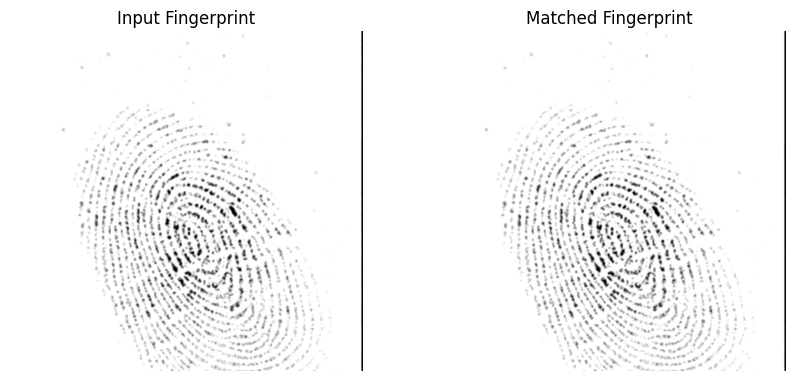

Match found with user: Olivia Thompson
Email: olivia.thompson@example.com


In [ ]:
#Tests
test_fp = dataset[3]["fingerprint_path"]
find_match(test_fp, dataset)



